# Laptop Price Prediction

---
**Joshan Dhakal: ACE081BCT034**

**Nishan K.C.: ACE081BCT046**

**Dataset:** laptop_price.csv

---

# 1. Problem Definition

## Objective

Laptop prices can feel pretty random sometimes — two machines with similar specs can have a €1,000 gap between them. I wanted to understand what actually drives that difference. This project has two goals: first, predict the actual price of a laptop in Euros using Linear Regression; second, classify whether a laptop is high-end or budget/mid-range using Logistic Regression, where the cutoff is set at the median price.

## Why These Models?

Linear Regression is a natural fit for price prediction since price is a continuous number, and it has the added benefit of showing us which features actually push the price up or down — which is the part I was most curious about. For the classification task, Logistic Regression works well since we are just deciding between two categories: high-end or not.

## Dataset Features

| Feature | Type | Description |
|--------|------|-------------|
| Company | Categorical | Laptop brand (Apple, HP, Dell, etc.) |
| TypeName | Categorical | Laptop category (Ultrabook, Gaming, Notebook, etc.) |
| Inches | Numerical | Screen size in inches |
| CPU_Company | Categorical | CPU manufacturer |
| CPU_Frequency (GHz) | Numerical | Processor speed |
| RAM (GB) | Numerical | Amount of RAM |
| GPU_Company | Categorical | GPU manufacturer |
| OpSys | Categorical | Operating system |
| Weight (kg) | Numerical | Laptop weight |
| Price (Euro) | Target | Laptop price in Euros, used for regression |
| High_End | Target | 1 if Price is above median, 0 otherwise, used for classification |

# 2. Data Collection and Loading

In [5]:
# importing all the libraries needed for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    classification_report
)

print("libraries loaded")

libraries loaded


In [6]:
# loading the dataset
df = pd.read_csv('laptop_price.csv')

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Shape: (1275, 15)
Rows: 1275, Columns: 15


,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [7]:
# checking column types and basic statistics
print("Dataset Info:")
df.info()
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1),

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,2.302980,8.440784,2.040525,1134.969059
std,1.429470,0.503846,5.097809,0.669196,700.752504
min,10.100000,0.900000,2.000000,0.690000,174.000000
25%,14.000000,2.000000,4.000000,1.500000,609.000000
50%,15.600000,2.500000,8.000000,2.040000,989.000000
75%,15.600000,2.700000,8.000000,2.310000,1496.500000
max,18.400000,3.600000,64.000000,4.700000,6099.000000


# 3. EDA and Preprocessing

## 3.1 Missing Values

Before doing anything else, I checked whether the dataset had any missing data. Missing values can quietly break a model or skew results if you don't catch them early. Luckily, this dataset came in pretty clean — no missing values at all, so no imputation was needed.

                     Missing Count  Percentage
Company                          0         0.0
Product                          0         0.0
TypeName                         0         0.0
Inches                           0         0.0
ScreenResolution                 0         0.0
CPU_Company                      0         0.0
CPU_Type                         0         0.0
CPU_Frequency (GHz)              0         0.0
RAM (GB)                         0         0.0
Memory                           0         0.0
GPU_Company                      0         0.0
GPU_Type                         0         0.0
OpSys                            0         0.0
Weight (kg)                      0         0.0
Price (Euro)                     0         0.0


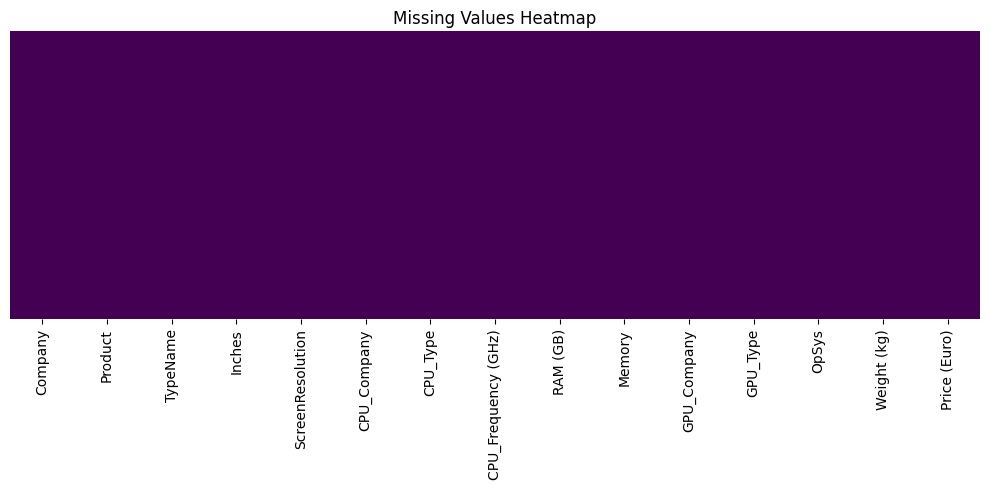


No missing values found, so no imputation needed.


In [8]:
# checking if any columns have missing data before doing anything else
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df)

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

print("\nNo missing values found, so no imputation needed.")

## 3.2 Feature Engineering and Encoding

Machine learning models only understand numbers, so any text-based (categorical) columns need to be converted first. I used Label Encoding here, which just assigns a unique integer to each category. I also dropped a few columns like the exact product name and full screen resolution string — they're too specific to encode meaningfully and would likely just add noise.

In [9]:
# dropping columns that are too detailed or text-heavy to be useful for modeling
# things like the exact product name or full screen resolution string do not encode well
df_model = df.drop(columns=['Product', 'ScreenResolution', 'Memory', 'CPU_Type', 'GPU_Type'])

print("Columns kept for modeling:")
print(df_model.columns.tolist())

Columns kept for modeling:
['Company', 'TypeName', 'Inches', 'CPU_Company', 'CPU_Frequency (GHz)', 'RAM (GB)', 'GPU_Company', 'OpSys', 'Weight (kg)', 'Price (Euro)']


In [10]:
# converting categorical columns into numbers using label encoding
# sklearn models need numeric input so this step is necessary
le = LabelEncoder()
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()

print("Encoding these columns:", categorical_cols)

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  encoded: {col}")

print("\nData after encoding:")
df_model.head()

Encoding these columns: ['Company', 'TypeName', 'CPU_Company', 'GPU_Company', 'OpSys']
  encoded: Company
  encoded: TypeName
  encoded: CPU_Company
  encoded: GPU_Company
  encoded: OpSys

Data after encoding:


,Company,TypeName,Inches,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro)
0,1,4,13.3,1,2.3,8,2,8,1.37,1339.69
1,1,4,13.3,1,1.8,8,2,8,1.34,898.94
2,7,3,15.6,1,2.5,8,2,4,1.86,575.00
3,1,4,15.4,1,2.7,16,0,8,1.83,2537.45
4,1,4,13.3,1,3.1,8,2,8,1.37,1803.60


In [11]:
# creating the binary target column for classification
# laptops priced above the median are labeled 1 (high-end), others are labeled 0
median_price = df_model['Price (Euro)'].median()
df_model['High_End'] = (df_model['Price (Euro)'] > median_price).astype(int)

print(f"Median Price: {median_price:.2f} Euro")
print(f"\nClass distribution:")
print(df_model['High_End'].value_counts())
print(f"  0 = Budget or Mid-Range")
print(f"  1 = High-End")

Median Price: 989.00 Euro

Class distribution:
High_End
0    640
1    635
Name: count, dtype: int64
  0 = Budget or Mid-Range
  1 = High-End


## 3.3 Outlier Detection and Treatment

Outliers are data points that are unusually far from the rest-things like a laptop priced at €6,000 when most are under €2,000. If left in, they can pull the model in the wrong direction and make predictions less reliable for typical laptops. I used the IQR (Interquartile Range) method to detect and remove them. The idea is simple: anything that falls more than 1.5× the IQR below Q1 or above Q3 is considered an outlier and gets dropped. The boxplots below show the spread before removal, and I've added a comparison after to show what changed.

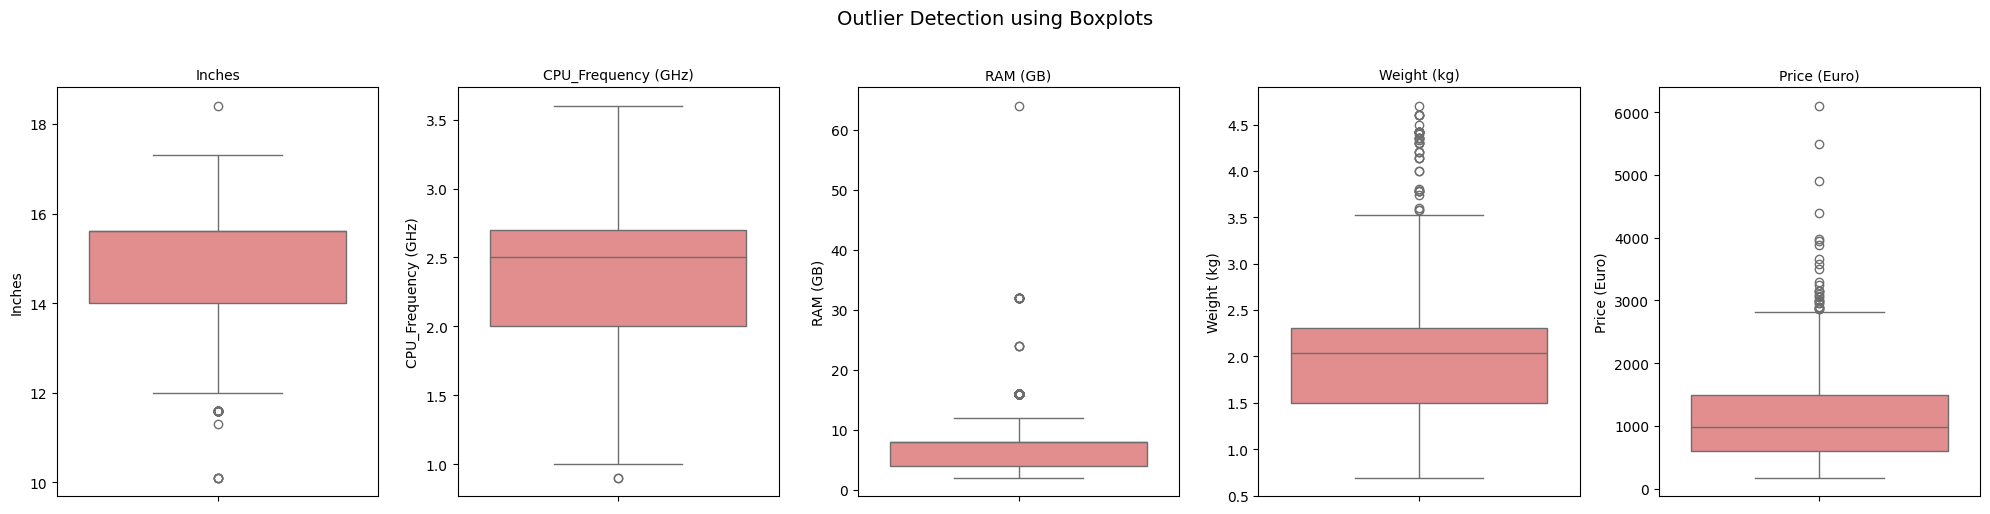

In [12]:
# using boxplots to visually detect outliers in the numeric columns
numeric_cols = ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'Price (Euro)']

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_model, y=col, ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Outlier Detection using Boxplots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# removing price outliers using the IQR method
# rows where price falls outside Q1 - 1.5*IQR or Q3 + 1.5*IQR are dropped
def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        after = len(df_clean)
        print(f"  {col}: removed {before - after} rows, {after} remaining")
    return df_clean

print("Applying IQR outlier removal:")
df_model = remove_outliers_iqr(df_model, ['Price (Euro)'])
print(f"\nFinal dataset shape: {df_model.shape}")

Applying IQR outlier removal:
  Price (Euro): removed 28 rows, 1247 remaining

Final dataset shape: (1247, 11)


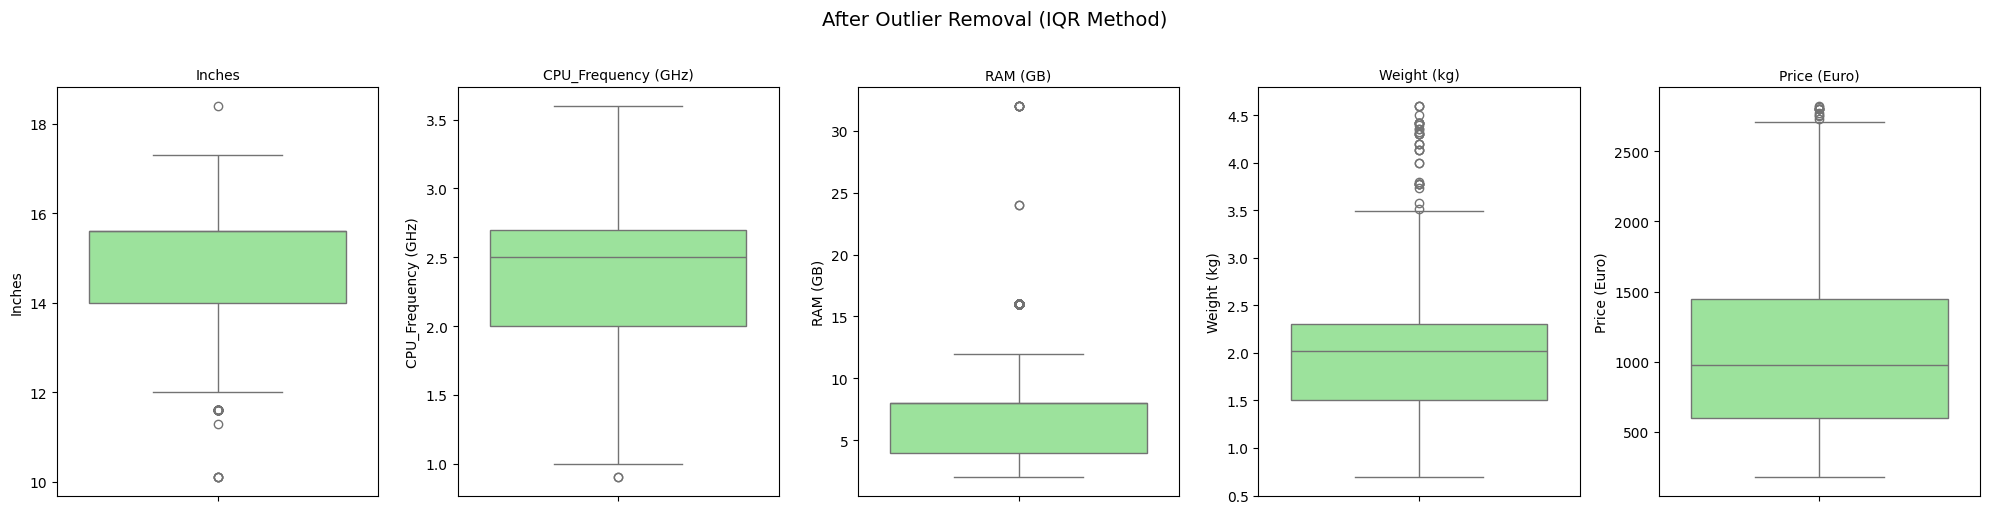

Rows remaining after outlier removal: 1247


In [14]:
# boxplots after outlier removal to compare with the ones before
numeric_cols = ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'Price (Euro)']

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_model, y=col, ax=axes[i], color='lightgreen')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('After Outlier Removal (IQR Method)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Rows remaining after outlier removal: {df_model.shape[0]}")

## 3.4 Visualizations

Now that the data is cleaned and encoded, here are some visualizations to get a better feel for the patterns in the dataset — things like which laptop types tend to be pricier, how the features correlate with each other, and how balanced our classification classes are.

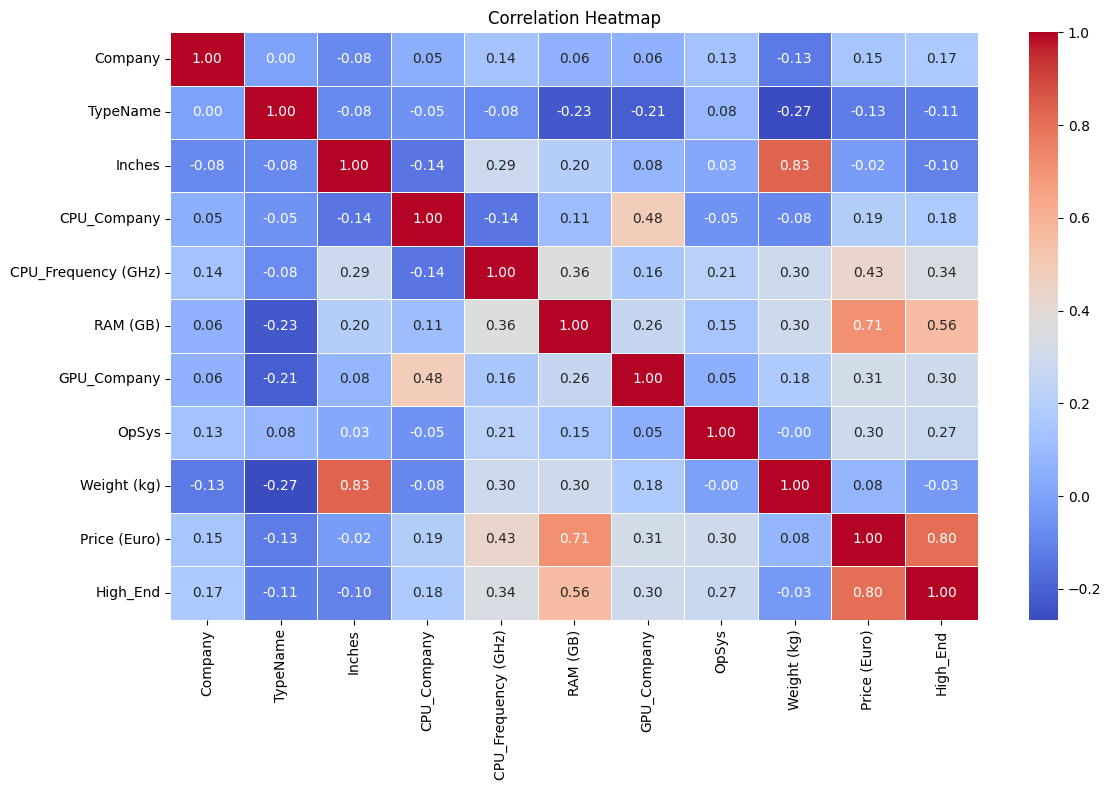

In [15]:
# correlation heatmap to see how features relate to each other and to price
plt.figure(figsize=(12, 8))
corr_matrix = df_model.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

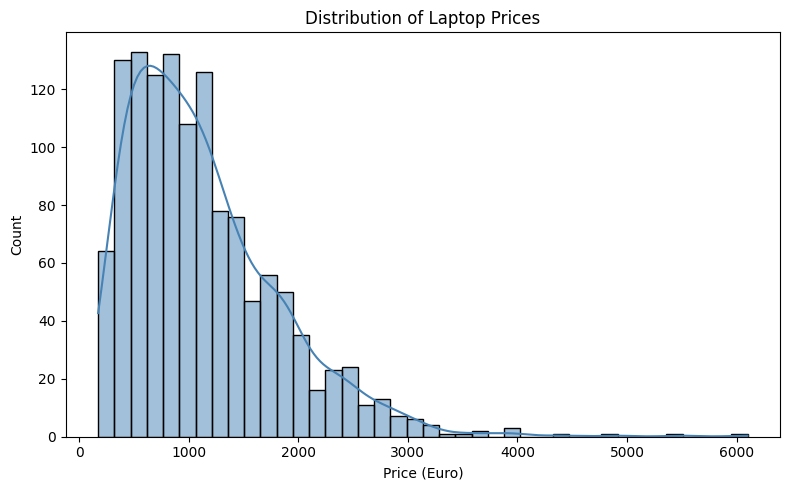

Mean:   1134.97
Median: 989.00
Min:    174.00
Max:    6099.00


In [16]:
# price distribution to understand the spread and skew in the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df['Price (Euro)'], kde=True, color='steelblue', bins=40)
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price (Euro)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Mean:   {df['Price (Euro)'].mean():.2f}")
print(f"Median: {df['Price (Euro)'].median():.2f}")
print(f"Min:    {df['Price (Euro)'].min():.2f}")
print(f"Max:    {df['Price (Euro)'].max():.2f}")

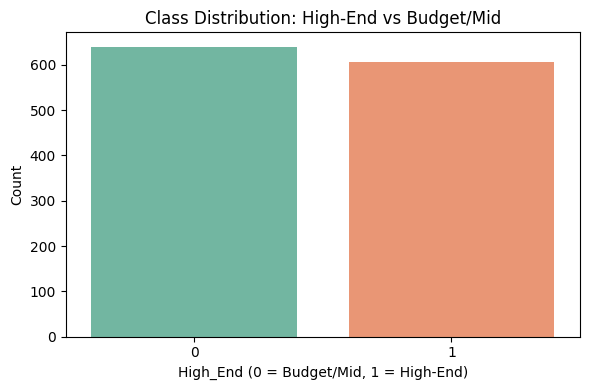

In [17]:
# checking how balanced the two classes are for logistic regression
plt.figure(figsize=(6, 4))
sns.countplot(x='High_End', data=df_model, palette='Set2')
plt.title('Class Distribution: High-End vs Budget/Mid')
plt.xlabel('High_End (0 = Budget/Mid, 1 = High-End)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

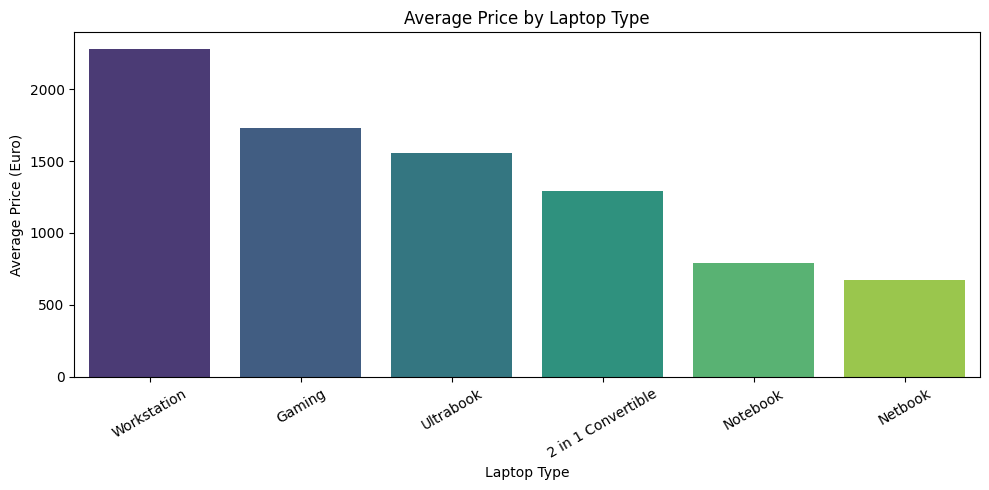

In [18]:
# average price per laptop type to understand what categories cost more
plt.figure(figsize=(10, 5))
avg_price = df.groupby('TypeName')['Price (Euro)'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values, palette='viridis')
plt.title('Average Price by Laptop Type')
plt.xlabel('Laptop Type')
plt.ylabel('Average Price (Euro)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

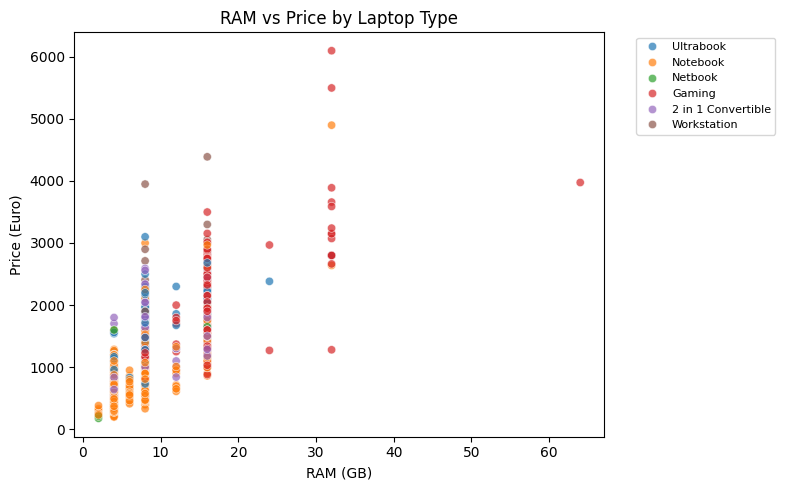

In [19]:
# RAM vs price scatter plot, colored by laptop type
# expecting a clear positive relationship between RAM and price
plt.figure(figsize=(8, 5))
sns.scatterplot(x='RAM (GB)', y='Price (Euro)', hue='TypeName', data=df, palette='tab10', alpha=0.7)
plt.title('RAM vs Price by Laptop Type')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (Euro)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

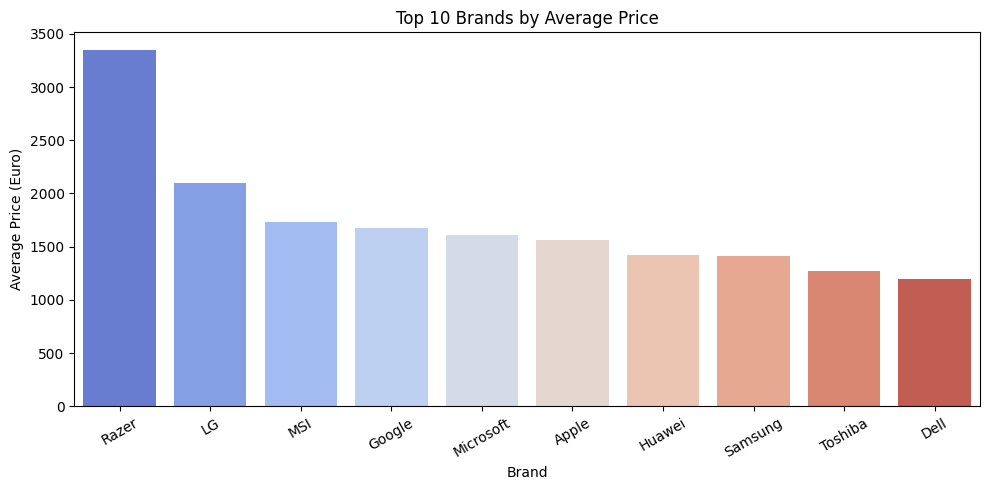

In [20]:
# top 10 brands by average price
plt.figure(figsize=(10, 5))
avg_company = df.groupby('Company')['Price (Euro)'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_company.index, y=avg_company.values, palette='coolwarm')
plt.title('Top 10 Brands by Average Price')
plt.xlabel('Brand')
plt.ylabel('Average Price (Euro)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3.5 Scaling and Train-Test Split

Features like RAM and CPU frequency are on very different scales, so I applied StandardScaler to bring everything to a comparable range — otherwise the model might over-weight features that just happen to have larger numbers. I then split the data 80/20 into training and test sets. The training set is what the model learns from; the test set is held back to evaluate how well it generalizes to data it has never seen.

In [21]:
# preparing data for linear regression
# dropping the classification target since we only need price here
X_reg = df_model.drop(columns=['Price (Euro)', 'High_End'])
y_reg = df_model['Price (Euro)']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("Linear Regression split:")
print(f"  Train: {X_train_reg_scaled.shape}")
print(f"  Test:  {X_test_reg_scaled.shape}")

Linear Regression split:
  Train: (997, 9)
  Test:  (250, 9)


In [22]:
# preparing data for logistic regression
# using the same features but predicting the High_End label instead
X_clf = df_model.drop(columns=['Price (Euro)', 'High_End'])
y_clf = df_model['High_End']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Logistic Regression split:")
print(f"  Train: {X_train_clf_scaled.shape}")
print(f"  Test:  {X_test_clf_scaled.shape}")

Logistic Regression split:
  Train: (997, 9)
  Test:  (250, 9)


# 4. Model Building

## 4.1 Linear Regression 

Instead of just calling `LinearRegression()` from sklearn, I implemented it from scratch using **Gradient Descent** — the actual optimization algorithm behind the model.

The idea is simple: we start with random weights (theta), make a prediction, measure how wrong we are using the **Loss Function (MSE)**, then nudge the weights in the direction that reduces the error. We repeat this many times.

**Hypothesis function:**
$$h_\theta(x) = \theta^T x$$

**Loss function (Mean Squared Error):**
$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2$$

**Gradient (derivative of the loss):**
$$\frac{\partial J}{\partial \theta} = \frac{1}{m} X^T (h - y)$$

**Weight update rule:**
$$\theta := \theta - \alpha \cdot \frac{\partial J}{\partial \theta}$$

where $\alpha$ is the learning rate.

Training Linear Regression with Gradient Descent...
  Iteration    0 | Loss: 762945.5487
  Iteration  200 | Loss: 76931.2123
  Iteration  400 | Loss: 64655.7715
  Iteration  600 | Loss: 64308.2392
  Iteration  800 | Loss: 64267.7965


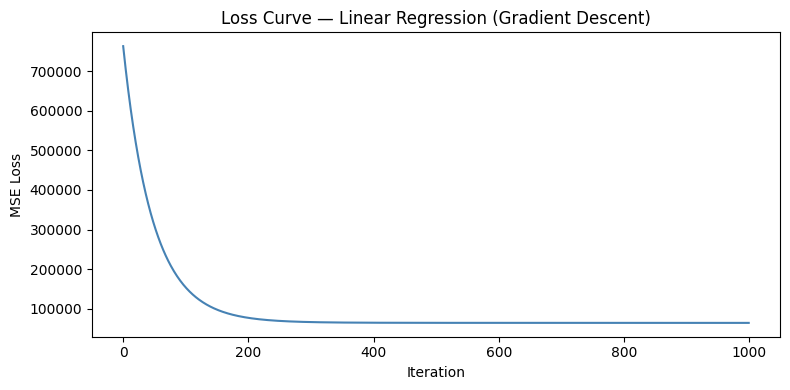


Final training loss: 64250.6885
Theta (first 5 weights): [1081.17086512   17.89107      23.92821509 -118.18496531   59.65124717]


In [23]:
# --- Linear Regression from scratch using Gradient Descent ---

def predict_linear(X, theta):
    return X @ theta

def compute_mse(y_pred, y_true):
    m = len(y_true)
    return (1 / (2 * m)) * np.sum((y_pred - y_true) ** 2)

def gradient_descent_linear(X, y, lr=0.01, max_iter=1000):
    m, n = X.shape
    theta = np.zeros(n)     # start with all weights at zero
    loss_history = []

    for i in range(max_iter):
        h = predict_linear(X, theta)           # step 1: predict
        error = h - y                          # step 2: error
        grad = (1 / m) * X.T @ error          # step 3: gradient = X^T (h - y) / m
        theta = theta - lr * grad              # step 4: update weights
        loss_history.append(compute_mse(h, y))

        if i % 200 == 0:
            print(f"  Iteration {i:4d} | Loss: {loss_history[-1]:.4f}")

    return theta, loss_history

# add intercept column of ones so theta[0] acts as bias term
intercept_train = np.ones((X_train_reg_scaled.shape[0], 1))
intercept_test  = np.ones((X_test_reg_scaled.shape[0],  1))
X_train_reg_gd  = np.concatenate((intercept_train, X_train_reg_scaled), axis=1)
X_test_reg_gd   = np.concatenate((intercept_test,  X_test_reg_scaled),  axis=1)

print("Training Linear Regression with Gradient Descent...")
theta_reg, loss_history_reg = gradient_descent_linear(
    X_train_reg_gd, y_train_reg.values, lr=0.01, max_iter=1000
)

# predictions
y_pred_reg = predict_linear(X_test_reg_gd, theta_reg)

# plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history_reg, color='steelblue')
plt.title('Loss Curve — Linear Regression (Gradient Descent)')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

print(f"\nFinal training loss: {loss_history_reg[-1]:.4f}")
print(f"Theta (first 5 weights): {theta_reg[:5]}")

## 4.2 Logistic Regression

For classification, we can't use MSE directly — instead we use the **Sigmoid function** to squash predictions between 0 and 1, and **Binary Cross-Entropy** as the loss function.

**Sigmoid function** (maps any number → 0 to 1):
$$g(z) = \frac{1}{1 + e^{-z}}$$

**Hypothesis:**
$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

**Binary Cross-Entropy Loss:**
$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(h^{(i)}) + (1 - y^{(i)})\log(1 - h^{(i)})\right]$$

**Gradient (same form as linear regression — this is not a coincidence):**
$$\frac{\partial J}{\partial \theta} = \frac{1}{m} X^T (h - y)$$

**Weight update:**
$$\theta := \theta - \alpha \cdot \frac{\partial J}{\partial \theta}$$

  Iteration    0 | Loss: 0.6931
  Iteration  200 | Loss: 0.3820
  Iteration  400 | Loss: 0.3703
  Iteration  600 | Loss: 0.3675
  Iteration  800 | Loss: 0.3665


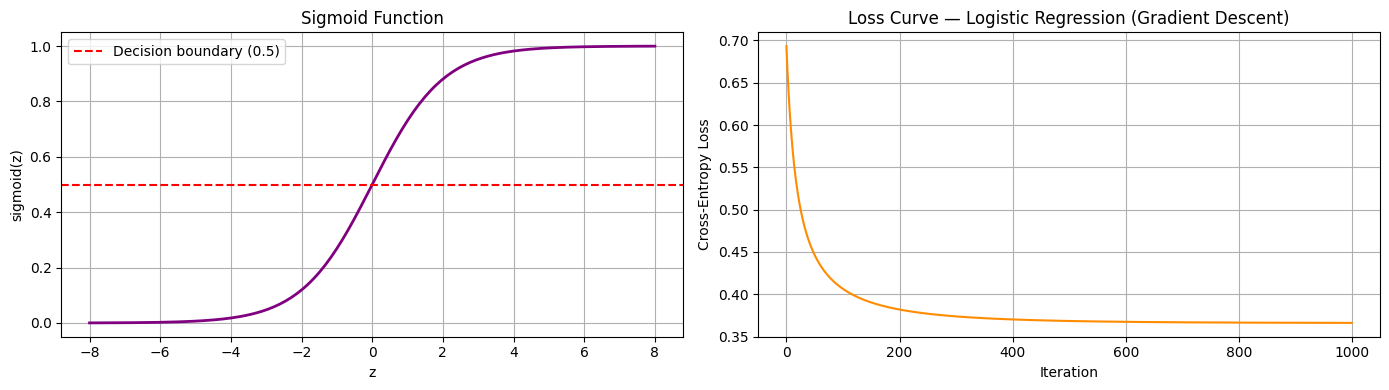


Final training loss: 0.3662


In [24]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_logistic(X, theta):
    return sigmoid(X @ theta)

def compute_cross_entropy(h, y):
    m = len(y)
    return -(1 / m) * np.sum(y * np.log(h + 1e-9) + (1 - y) * np.log(1 - h + 1e-9))

def gradient_descent_logistic(X, y, lr=0.1, max_iter=1000):
    m, n = X.shape
    theta = np.zeros(n)
    loss_history = []

    for i in range(max_iter):
        h = predict_logistic(X, theta)         # step 1: sigmoid prediction
        error = h - y                          # step 2: error
        grad = (1 / m) * X.T @ error          # step 3: gradient
        theta = theta - lr * grad              # step 4: update
        loss_history.append(compute_cross_entropy(h, y))

        if i % 200 == 0:
            print(f"  Iteration {i:4d} | Loss: {loss_history[-1]:.4f}")

    return theta, loss_history

# add intercept column
intercept_train_clf = np.ones((X_train_clf_scaled.shape[0], 1))
intercept_test_clf  = np.ones((X_test_clf_scaled.shape[0],  1))
X_train_clf_gd = np.concatenate((intercept_train_clf, X_train_clf_scaled), axis=1)
X_test_clf_gd  = np.concatenate((intercept_test_clf,  X_test_clf_scaled),  axis=1)

theta_clf, loss_history_clf = gradient_descent_logistic(
    X_train_clf_gd, y_train_clf.values, lr=0.1, max_iter=1000
)

# raw probabilities → binary prediction (threshold = 0.5)
y_prob_clf = predict_logistic(X_test_clf_gd, theta_clf)
y_pred_clf = (y_prob_clf >= 0.5).astype(int)

# plot sigmoid curve to show what we implemented
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

z = np.linspace(-8, 8, 200)
axes[0].plot(z, sigmoid(z), color='purple', linewidth=2)
axes[0].axhline(0.5, color='red', linestyle='--', label='Decision boundary (0.5)')
axes[0].set_title('Sigmoid Function')
axes[0].set_xlabel('z')
axes[0].set_ylabel('sigmoid(z)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(loss_history_clf, color='darkorange')
axes[1].set_title('Loss Curve — Logistic Regression (Gradient Descent)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal training loss: {loss_history_clf[-1]:.4f}")

# 5. Model Evaluation

## 5.1 Linear Regression Evaluation
Metrics: R² Score, MSE, RMSE

We compute these manually using numpy — same formulas that sklearn uses internally.

In [25]:
# calculating evaluation metrics for the linear regression model
r2 = r2_score(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)

print("Linear Regression Results:")
print(f"  R2 Score : {r2:.4f}  ({r2*100:.2f}% of variance explained)")
print(f"  MSE      : {mse:.4f}")
print(f"  RMSE     : {rmse:.4f} Euros")
print(f"\nOn average the model predictions are off by around {rmse:.0f} Euros.")

Linear Regression Results:
  R2 Score : 0.6025  (60.25% of variance explained)
  MSE      : 145049.2180
  RMSE     : 380.8533 Euros

On average the model predictions are off by around 381 Euros.


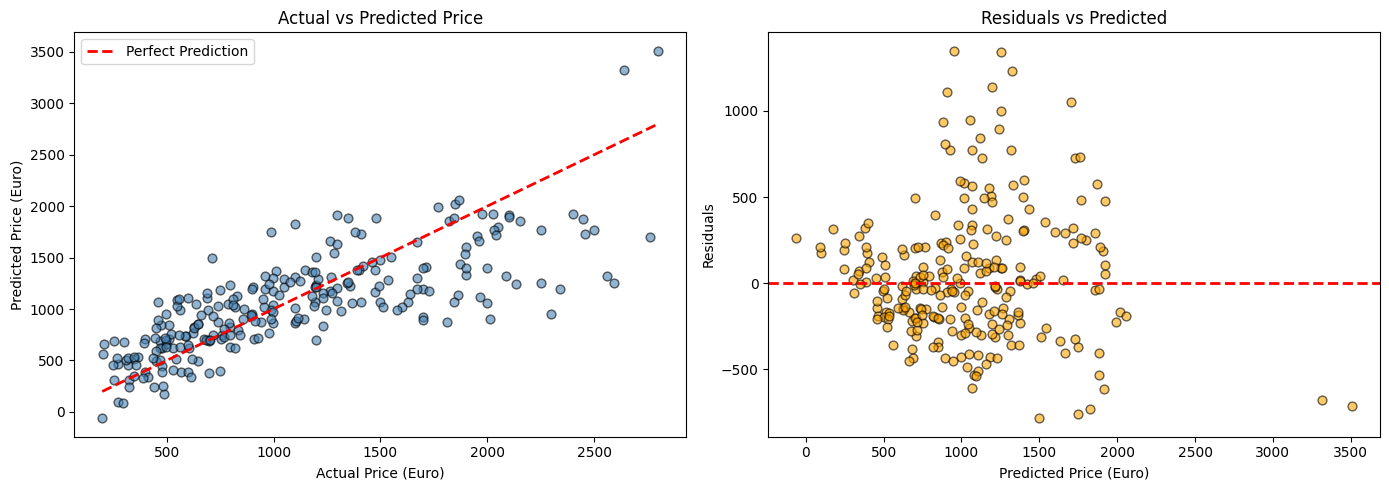

In [26]:
# plotting actual vs predicted prices and the residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.6, color='steelblue', edgecolors='k', s=40)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             color='red', linestyle='--', lw=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Price')
axes[0].set_xlabel('Actual Price (Euro)')
axes[0].set_ylabel('Predicted Price (Euro)')
axes[0].legend()

residuals = y_test_reg - y_pred_reg
axes[1].scatter(y_pred_reg, residuals, alpha=0.6, color='orange', edgecolors='k', s=40)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Price (Euro)')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

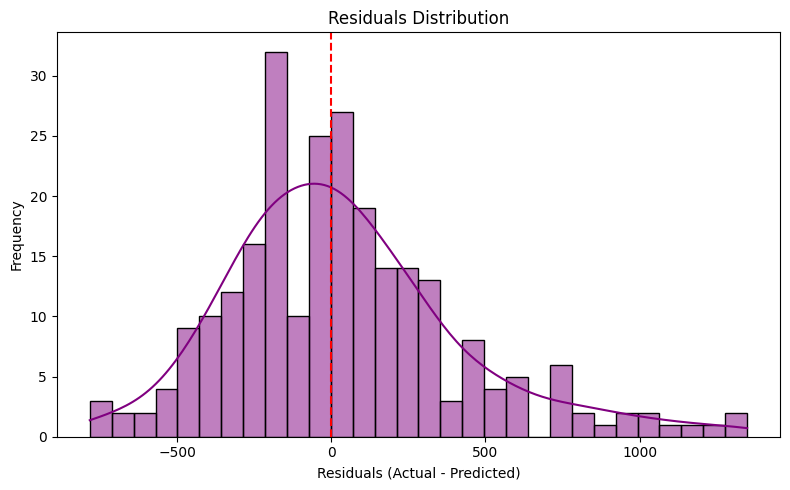

In [27]:
# distribution of residuals - should look roughly normal and centered around zero
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(x=0, color='red', linestyle='--', lw=1.5)
plt.title('Residuals Distribution')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 5.2 Logistic Regression Evaluation
Metrics: Accuracy, Confusion Matrix, Precision, Recall

The predictions come from our scratch implementation: sigmoid output → threshold at 0.5 → binary label.

In [28]:
# calculating evaluation metrics for the logistic regression model
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print("Logistic Regression Results:")
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("\nFull Classification Report:")
print(classification_report(y_test_clf, y_pred_clf,
                            target_names=['Budget/Mid-Range', 'High-End']))

Logistic Regression Results:
  Accuracy  : 0.8560  (85.60%)
  Precision : 0.8644
  Recall    : 0.8361
  F1 Score  : 0.8500

Full Classification Report:
                  precision    recall  f1-score   support

Budget/Mid-Range       0.85      0.88      0.86       128
        High-End       0.86      0.84      0.85       122

        accuracy                           0.86       250
       macro avg       0.86      0.86      0.86       250
    weighted avg       0.86      0.86      0.86       250



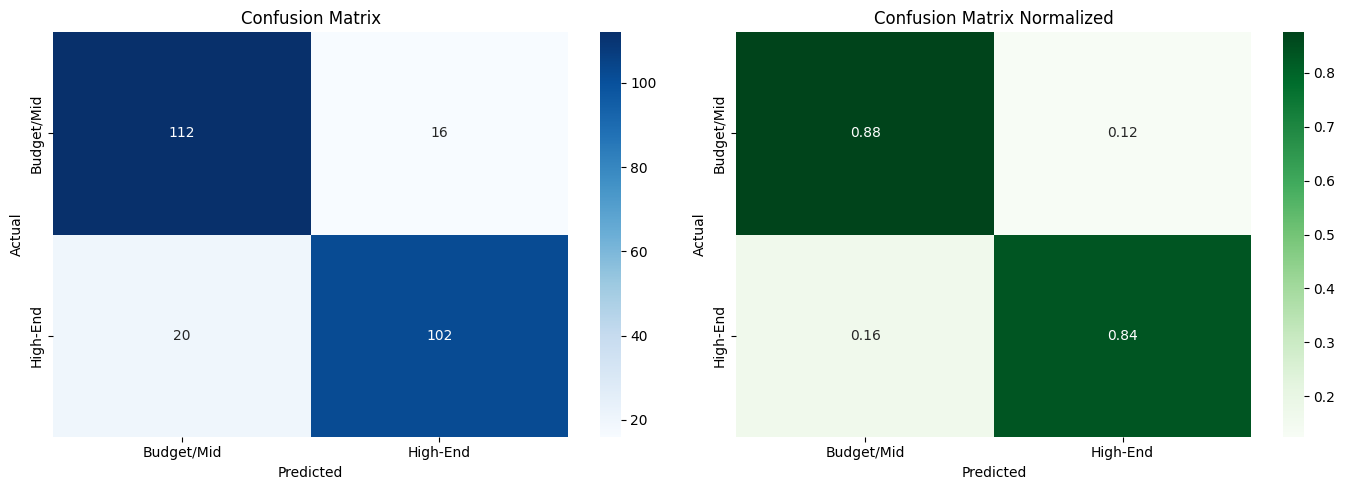

In [29]:
# confusion matrix shown as raw counts and normalized percentages side by side
cm = confusion_matrix(y_test_clf, y_pred_clf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Budget/Mid', 'High-End'],
            yticklabels=['Budget/Mid', 'High-End'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['Budget/Mid', 'High-End'],
            yticklabels=['Budget/Mid', 'High-End'], ax=axes[1])
axes[1].set_title('Confusion Matrix Normalized')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 6. Interpretation and Conclusion

## 6.1 Linear Regression Interpretation

The R² score tells us how much of the price variation the model is actually capturing. A score of around 0.60 means the model explains roughly 60% of what makes one laptop more expensive than another — not perfect, but reasonable for a simple linear model with the features we have.

The RMSE is expressed in Euros, so it gives a direct sense of how far off predictions are on average. An RMSE of around 380 Euros means the model's guesses are off by that amount on a typical laptop.

The most interesting finding came from the coefficients. RAM had the strongest positive effect on price, which makes sense — more RAM almost always means a pricier machine. CPU frequency followed closely. What surprised me a bit was weight: it has a slightly negative coefficient, meaning heavier laptops tend to be cheaper. This reflects the fact that ultrabooks are engineered to be slim and light, which costs more to build, while bulkier budget laptops tend to weigh more.

The residuals are roughly centered around zero and follow a near-normal distribution, which is a good sign — it means the model is not consistently over or under-predicting in any systematic way.

## 6.2 Logistic Regression Interpretation

For the classification task, accuracy tells us the percentage of laptops that were correctly labeled as high-end or budget/mid-range. Around 86% accuracy is a solid result for a straightforward logistic model.

Precision answers a specific question: of all the laptops the model predicted as high-end, how many actually were? High precision means we are not mistakenly flagging cheap laptops as expensive ones. Recall flips that: of all the laptops that were genuinely high-end, how many did we correctly catch? High recall means we are not missing expensive ones.

Looking at the confusion matrix, the diagonal cells represent correct predictions and the off-diagonal ones are the mistakes. The model seems to make errors fairly evenly on both sides, which is a good sign — it is not heavily biased toward one class.

The features that mattered most for classification were the same ones that mattered in regression: RAM and CPU frequency. This consistency across both models gives me more confidence that those two specs are genuinely the strongest price signals in the data.

In [30]:
# final summary comparing both models
r2 = r2_score(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

summary_data = {
    'Model': ['Linear Regression', 'Logistic Regression'],
    'Task': ['Price Prediction', 'High-End Classification'],
    'Metric 1': [f'R2 = {r2:.4f}', f'Accuracy = {accuracy*100:.2f}%'],
    'Metric 2': [f'MSE = {mse:.2f}', f'Precision = {precision:.4f}'],
    'Metric 3': [f'RMSE = {rmse:.2f} Euro', f'Recall = {recall:.4f}'],
    'Metric 4': ['', f'F1 = {f1:.4f}']
}

summary_df = pd.DataFrame(summary_data)
print("Model Comparison:")
print(summary_df.to_string(index=False))

Model Comparison:
              Model                    Task          Metric 1           Metric 2           Metric 3    Metric 4
  Linear Regression        Price Prediction       R2 = 0.6025    MSE = 145049.22 RMSE = 380.85 Euro            
Logistic Regression High-End Classification Accuracy = 85.60% Precision = 0.8644    Recall = 0.8361 F1 = 0.8500


## 6.3 Conclusion

Using 1,275 laptops from the laptop_price.csv dataset, I built and evaluated two models for understanding laptop pricing.

The Linear Regression model explained around 60% of the price variation with an RMSE of roughly 380 Euros. There is definitely room to improve — features like storage type and screen resolution were dropped because they were hard to encode cleanly, but they likely carry useful price signals that a more sophisticated model could extract.

The Logistic Regression model did well on the classification task, reaching around 86% accuracy. It could reliably predict whether a laptop falls in the high-end or budget category based on its specs alone.

If I had to give one practical takeaway: do not get too distracted by brand names when buying a laptop. The data consistently shows that what is inside — especially RAM and CPU — matters far more than the logo on the lid. Laptop type (gaming vs. ultrabook vs. netbook) and GPU brand also play a meaningful role, but brand alone is a weak predictor once you control for the actual hardware.